In [1]:
from sionna.rt import load_scene, RadioMapSolver, Camera, transform_mesh
from pathlib import Path
import json
import sys

# Add parent directory to path to import from src/
sys.path.append(str(Path(__file__).parent.parent) if '__file__' in globals() else str(Path.cwd().parent))

from src.base_station import set_tx_antenna_array, add_base_station
from src.user_equipment import set_rx_antenna_array

jitc_llvm_init(): LLVM API initialization failed ..


In [2]:
scene_dir = Path("../scenes/boston/")
scene_xml_path = scene_dir / "scene.xml"
building_positions_path = scene_dir / "buildings.json"

In [3]:
def load_building_positions(building_positions_path):
    """loads building positions from .json file at building_positions_path"""
    with open(building_positions_path, 'r') as f:
        return json.load(f)

def get_antenna_position(building_positions, scene_center=[0.0, 0.0], antenna_height_offset=10.0, shift_factor=0.5):
    """
    Find the highest building and calculate a heuristic-based antenna position on the rooftop
    to minimize self-shadowing by shifting towards scene center.
    
    Args:
        building_positions: Dictionary of building data
        scene_center: Scene center coordinates [x, y] (from ground/scene bounds, not buildings). Defaults to [0.0, 0.0]
        antenna_height_offset: Height offset for antenna above rooftop (meters)
        shift_factor: Factor controlling shift towards center
        
    Returns:
        tuple: (building_id, antenna_position) where antenna_position is [x, y, z]
    """
    if not building_positions:
        return None, None
    
    # Single pass: find highest building
    highest_building_id = None
    highest_building_data = None
    max_z = float('-inf')
    
    for building_id, data in building_positions.items():
        z_coord = data['centroid'][2]
        if z_coord > max_z:
            max_z = z_coord
            highest_building_id = building_id
            highest_building_data = data
    
    if highest_building_id is None:
        return None, None
    
    # Extract building data
    centroid = highest_building_data['centroid']
    min_bounds = highest_building_data['min']
    max_bounds = highest_building_data['max']
    dimensions = highest_building_data['dimensions']
    
    # Direction vector from centroid to scene center (normalized)
    dx = scene_center[0] - centroid[0]
    dy = scene_center[1] - centroid[1]
    direction_length = (dx**2 + dy**2)**0.5
    if direction_length > 0:
        dx /= direction_length
        dy /= direction_length
    
    # Shift magnitude based on roof size
    roof_size = (dimensions[0] + dimensions[1]) / 2
    shift_magnitude = roof_size * shift_factor
    
    # Calculate antenna position (shifted towards center, clamped to roof bounds)
    antenna_x = max(min_bounds[0], min(max_bounds[0], centroid[0] + dx * shift_magnitude))
    antenna_y = max(min_bounds[1], min(max_bounds[1], centroid[1] + dy * shift_magnitude))
    antenna_z = centroid[2] + antenna_height_offset
    
    return highest_building_id, [antenna_x, antenna_y, antenna_z]

In [4]:
scene = load_scene(scene_xml_path)
building_positions = load_building_positions(building_positions_path)
highest_building_id, antenna_position = get_antenna_position(building_positions)

measurement_surface = scene.objects["ground"].clone(as_mesh=True)
transform_mesh(measurement_surface,
            translation=[0,0,1.5])

2026-01-04 18:47:25 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).


In [5]:
# Get scene bounds and corners
try:
    # Try accessing bbox attribute (if available in Sionna RT)
    bbox_min = scene.bbox.min
    bbox_max = scene.bbox.max
    print(f"Scene bounding box:")
    print(f"  Min: [{bbox_min[0]:.2f}, {bbox_min[1]:.2f}, {bbox_min[2]:.2f}]")
    print(f"  Max: [{bbox_max[0]:.2f}, {bbox_max[1]:.2f}, {bbox_max[2]:.2f}]")
    
    # Calculate all 8 corners of the bounding box
    corners = [
        [bbox_min[0], bbox_min[1], bbox_min[2]],  # Bottom-left-back
        [bbox_min[0], bbox_min[1], bbox_max[2]],  # Bottom-left-front
        [bbox_min[0], bbox_max[1], bbox_min[2]],  # Top-left-back
        [bbox_min[0], bbox_max[1], bbox_max[2]],  # Top-left-front
        [bbox_max[0], bbox_min[1], bbox_min[2]],  # Bottom-right-back
        [bbox_max[0], bbox_min[1], bbox_max[2]],  # Bottom-right-front
        [bbox_max[0], bbox_max[1], bbox_min[2]],  # Top-right-back
        [bbox_max[0], bbox_max[1], bbox_max[2]],  # Top-right-front
    ]
    
    print(f"\nScene corners (8 corners of bounding box):")
    for i, corner in enumerate(corners, 1):
        print(f"  Corner {i}: [{corner[0]:.2f}, {corner[1]:.2f}, {corner[2]:.2f}]")
    
    # For 2D ground plane edges (z=0 or min z)
    ground_corners = [
        [bbox_min[0], bbox_min[1], bbox_min[2]],  # Bottom-left
        [bbox_min[0], bbox_max[1], bbox_min[2]],  # Top-left
        [bbox_max[0], bbox_max[1], bbox_min[2]],  # Top-right
        [bbox_max[0], bbox_min[1], bbox_min[2]],  # Bottom-right
    ]
    
    print(f"\nGround plane corners (4 corners at z={bbox_min[2]:.2f}):")
    for i, corner in enumerate(ground_corners, 1):
        print(f"  Corner {i}: [{corner[0]:.2f}, {corner[1]:.2f}, {corner[2]:.2f}]")
    
    scene_bounds = {
        'min': [bbox_min[0], bbox_min[1], bbox_min[2]],
        'max': [bbox_max[0], bbox_max[1], bbox_max[2]],
        'center': [(bbox_min[0] + bbox_max[0])/2, (bbox_min[1] + bbox_max[1])/2, (bbox_min[2] + bbox_max[2])/2],
        'size': [bbox_max[0] - bbox_min[0], bbox_max[1] - bbox_min[1], bbox_max[2] - bbox_min[2]],
        'corners': corners,
        'ground_corners': ground_corners
    }
    
except AttributeError:
    print("Scene bbox attribute not available. Trying alternative method...")
    # Alternative: access through Mitsuba scene
    try:
        mi_scene = scene.mi_scene
        bbox = mi_scene.bbox()
        bbox_min = bbox.min
        bbox_max = bbox.max
        print(f"Scene bounding box (from Mitsuba):")
        print(f"  Min: [{bbox_min[0]:.2f}, {bbox_min[1]:.2f}, {bbox_min[2]:.2f}]")
        print(f"  Max: [{bbox_max[0]:.2f}, {bbox_max[1]:.2f}, {bbox_max[2]:.2f}]")
    except:
        print("Could not access scene bounds. Scene may need to be finalized first.")
        print("Try calling scene.finalize() or check scene documentation.")

Scene bbox attribute not available. Trying alternative method...
Scene bounding box (from Mitsuba):
  Min: [-750.00, -750.00, 0.00]
  Max: [750.00, 750.00, 210.50]


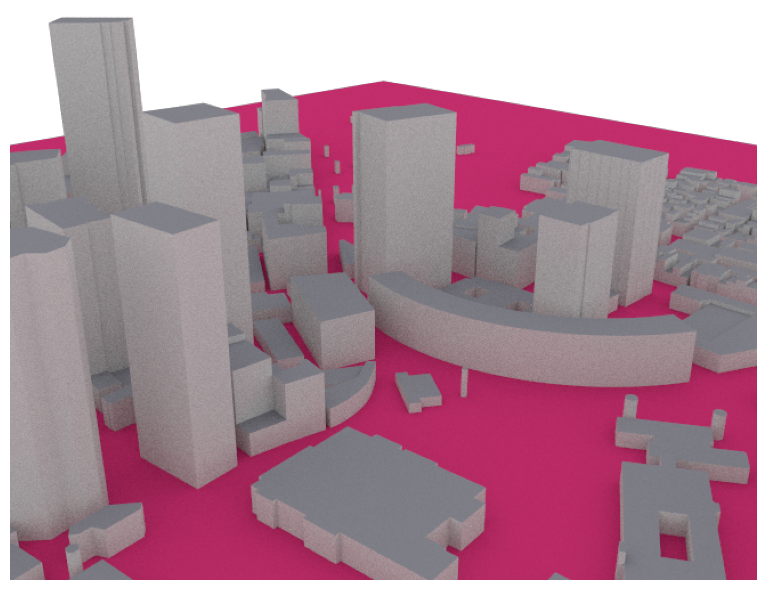

In [6]:
# Position camera at a good viewing distance from the scene center
camera = Camera(position=[500, 500, 300], look_at=[0, 0, 0])  # Default position above scene center
scene.render(camera=camera);

In [7]:
set_tx_antenna_array(
    scene,
    num_rows=8,
    num_cols=8,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",
    polarization="cross")

add_base_station(
    scene,
    "BS_0",
    position=antenna_position,  # BS is located at heuristic rooftop position to minimize self-shadowing
    num_sectors=6,  # 8x8 requires many sectors to cover all directions
    mechanical_tilt=10.0,  # Mechanical tilt of the antenna
    azimuth_offset=0.0,  # Azimuth offset of the antenna for the first sector
    tx_power_dbm=50.0,
    display_radius=20.0
)

set_rx_antenna_array(
    scene,
    num_rows=2,
    num_cols=2,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="hw_dipole",
    polarization="VH"
)

Antenna Array Configuration Set:
  - Array: 8x8 (128 elements)
  - Pattern: tr38901, Polarization: cross
  - Spacing: V=0.5λ, H=0.5λ
  - Estimated beamwidth: [15.3]°
Added BS_0_sector_1 at position [[254.29, -397.219, 220.5]], azimuth 0.0°
Added BS_0_sector_2 at position [[254.29, -397.219, 220.5]], azimuth 60.0°
Added BS_0_sector_3 at position [[254.29, -397.219, 220.5]], azimuth 120.0°
Added BS_0_sector_4 at position [[254.29, -397.219, 220.5]], azimuth 180.0°
Added BS_0_sector_5 at position [[254.29, -397.219, 220.5]], azimuth 240.0°
Added BS_0_sector_6 at position [[254.29, -397.219, 220.5]], azimuth 300.0°

Base Station 'BS_0' Summary:
  - Sectors: 6
  - Mechanical tilt: 10.0°
  - TX Power: 50.0 dBm
  - Position: [[254.29], [-397.219], [220.5]] m
UE Antenna Array Configuration Set:
  - Array: 2x2 (8 elements)
  - Pattern: hw_dipole, Polarization: VH
  - Spacing: V=0.5λ, H=0.5λ


In [8]:
scene.objects

{'no-name-1': <sionna.rt.scene_object.SceneObject at 0x7f939250f390>,
 'no-name-2': <sionna.rt.scene_object.SceneObject at 0x7f9392527fd0>,
 'ground': <sionna.rt.scene_object.SceneObject at 0x7f93921c6e50>}

In [9]:
scene.preview();

In [ ]:
rm_solver = RadioMapSolver()
rm = rm_solver(scene,
               measurement_surface=measurement_surface,
               diffuse_reflection=True,
               diffraction=True,
               edge_diffraction=True,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**8) # If you increase: less noise, but more memory required

In [ ]:
scene.objects

In [ ]:
scene.preview(radio_map=rm, rm_db_scale=True, rm_metric="path_gain");

In [ ]:
rm.show(metric="path_gain", tx=0);

In [ ]:
rm.show(metric="path_gain", tx=1);

In [ ]:
rm.show(metric="path_gain", tx=2);